# Mestrado em Inteligência Artificial 25/26


# Practical 3 — Dynamic Programming (Jack's Car Rental)
## Policy Evaluation, Policy Improvement, Policy Iteration, Value Iteration


In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'agents').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.mplconfig'))

from experiments.car_rental_dp import (
    bellman_expectation_backup_v,
    bellman_optimality_backup_v,
    policy_evaluation,
    policy_improvement,
    policy_iteration,
    q_from_v,
    value_iteration,
    zeros_V,
)
from mdps.car_rental import CarRentalMDP, CarRentalParams, poisson_pmf_truncated
from plots.car_rental import plot_poisson_distributions, plot_policy, plot_values

np.set_printoptions(precision=3, suppress=True)


## 1) Car Rental MDP

State:  
- `s = (n1, n2)`: number of cars at location 1 and 2 at end of day.

Action:  
- `a`: cars moved overnight from location 1 to location 2. Negative means the opposite direction.

Dynamics:  
- requests and returns are independent Poisson random variables.

Reward:  
- rental revenue minus moving cost.


### Config


In [2]:
params = CarRentalParams()
params


CarRentalParams(max_cars_1=20, max_cars_2=20, max_moveable=5, revenue_per_rental=10.0, cost_per_moved=2.0, lambdas=(3.0, 4.0, 3.0, 2.0), max_requests_1=8, max_requests_2=10, max_returns_1=8, max_returns_2=8)

## Poisson Distribution


[0.05  0.149 0.224 0.224 0.168 0.101 0.05  0.022 0.012]


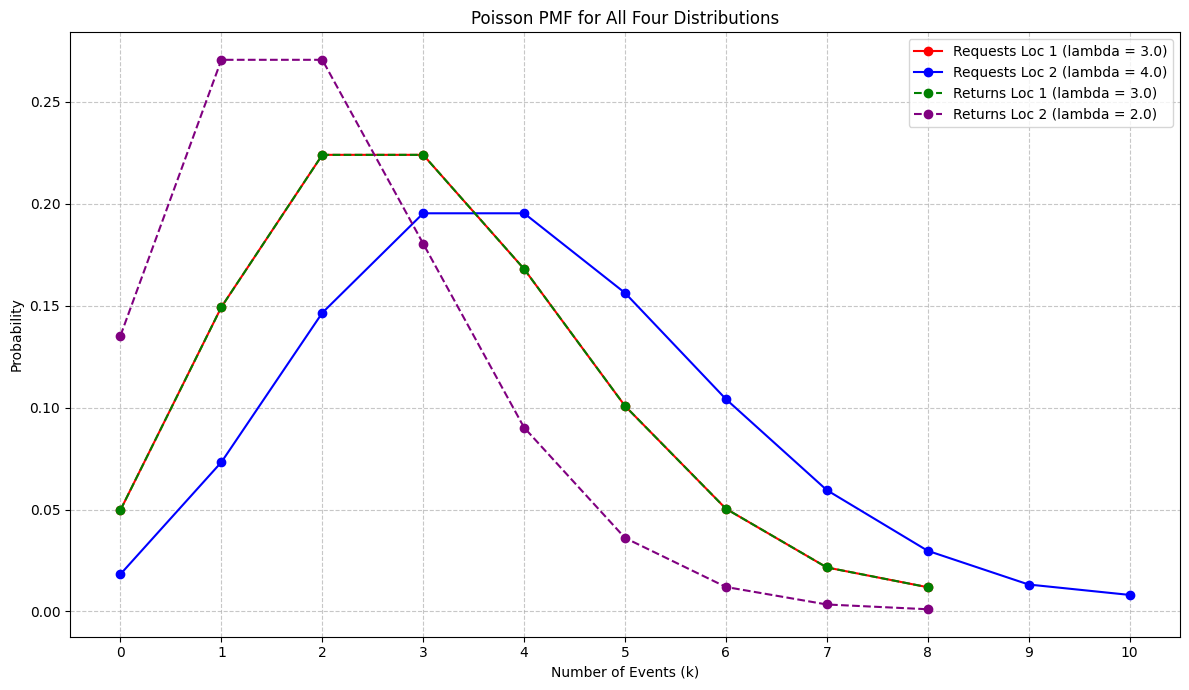

In [3]:
print(poisson_pmf_truncated(3, 8))
fig, ax = plot_poisson_distributions(params)
plt.show()


### MDP


In [4]:
mdp = CarRentalMDP(params)
mdp.states()[:5], mdp.possible_actions((10, 10))[:5], mdp.possible_actions((10, 10))[-5:]


([(0, 0), (0, 1), (0, 2), (0, 3), (0, 4)],
 [-5, -4, -3, -2, -1],
 [1, 2, 3, 4, 5])

In [5]:
mdp.req1


array([0.05 , 0.149, 0.224, 0.224, 0.168, 0.101, 0.05 , 0.022, 0.012])

## 2) One-step expected return backup


In [6]:
V0 = zeros_V(mdp)
sample_state = (10, 10)
sample_action = 0
q_from_v(mdp, V0, sample_state, sample_action, gamma=0.9)


69.90579114941738

In [7]:
policy0 = {state: 0 for state in mdp.states()}
state = (10, 10)
expectation_backup = bellman_expectation_backup_v(mdp, V0, state, policy0, gamma=0.9)
optimality_backup = bellman_optimality_backup_v(mdp, V0, state, gamma=0.9)
expectation_backup, optimality_backup


(69.90579114941738, 69.90579114941738)

## 3) Iterative Policy Evaluation


In [8]:
gamma = 0.9
V_eval, eval_iters = policy_evaluation(mdp, policy0, gamma=gamma, theta=1e-4)
print('Converged in iterations:', eval_iters)
V_eval[:5, :5]


Converged in iterations: 126


array([[407.005, 416.979, 426.845, 436.476, 445.76 ],
       [416.825, 426.799, 436.665, 446.296, 455.58 ],
       [426.059, 436.033, 445.898, 455.53 , 464.813],
       [434.302, 444.276, 454.142, 463.773, 473.057],
       [441.362, 451.336, 461.201, 470.833, 480.116]])

## 4) Greedy Policy Improvement


In [9]:
policy1, stable = policy_improvement(mdp, V_eval, policy0, gamma=gamma)
print('Policy stable:', stable)
policy1[(10, 10)], policy1[(5, 15)], policy1[(15, 5)]


Policy stable: False


(3, 0, 5)

## 5) Policy Iteration


In [10]:
V_pi, pi_pi, hist = policy_iteration(mdp, gamma=gamma, theta=1e-4, max_outer=20)
print('Policy Iteration outer loops:', len(hist))
len(pi_pi), V_pi.shape


Policy Iteration outer loops: 5


(441, (21, 21))

## 6) Value Iteration


In [11]:
V_vi, pi_vi, it_vi = value_iteration(mdp, gamma=gamma, theta=1e-4)
print('Value Iteration iterations:', it_vi)
len(pi_vi), V_vi.shape


Value Iteration iterations: 126


(441, (21, 21))

## 7) Plotting utilities


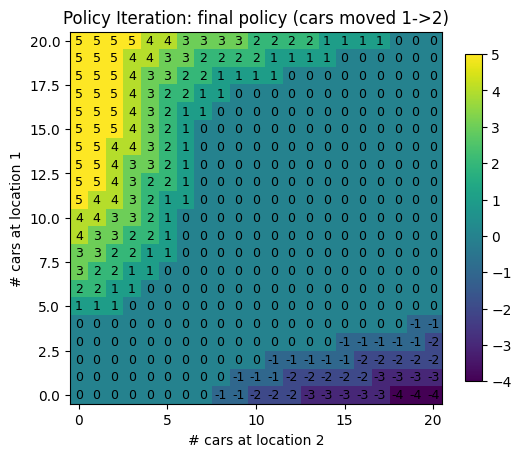

In [12]:
fig, ax = plot_policy(mdp, pi_pi, title='Policy Iteration: final policy (cars moved 1->2)')
plt.show()


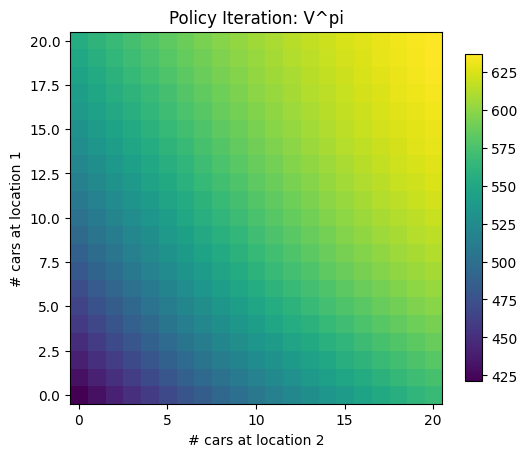

In [13]:
fig, ax = plot_values(mdp, V_pi, title='Policy Iteration: V^pi')
plt.show()


## 8) Run experiments


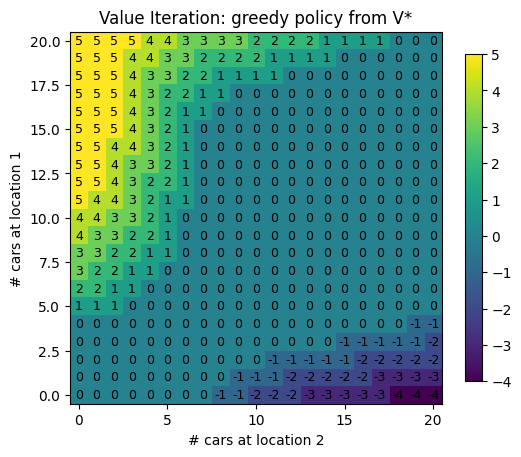

In [14]:
fig, ax = plot_policy(mdp, pi_vi, title='Value Iteration: greedy policy from V*')
plt.show()


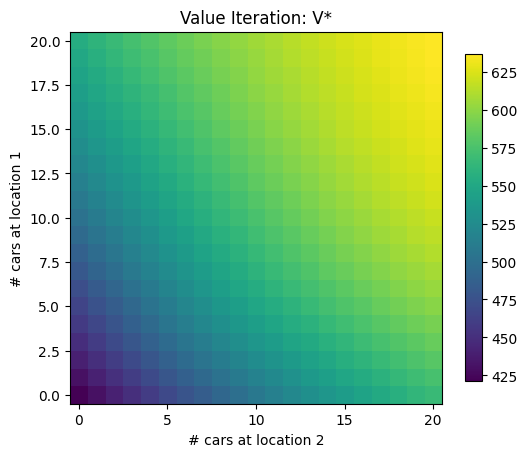

In [15]:
fig, ax = plot_values(mdp, V_vi, title='Value Iteration: V*')
plt.show()
